In [205]:
import copy
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold
import numpy as np

In [207]:
#NN model
#1 hidden layer, 32 nuerons
#uses full batch gradient descent to update weights
class RegressionNN(nn.Module):
    def __init__(self, input_size):
        super(RegressionNN, self).__init__()
        self.fc1 = nn.Linear(input_size, 32)
        self.output = nn.Linear(32, 1)
        self.relu = nn.ReLU()
        
    def forward(self, x):
        x = self.relu(self.fc1(x)) #using ReLU activation function
        x = self.output(x)
        return x

In [209]:
#Training
def train_model(X_train, y_train, X_val, y_val, n_epochs=1000): #max iteration 1,000
    model = RegressionNN(X_train.shape[1])
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001) #dynamic learning rate 0.001 - recommended, optimized with an adaptive learning rate
    #the closer it gets to the local min the smaller the jumps.
    
    # For plotting
    train_losses = []
    val_losses = []
    
    for epoch in range(n_epochs):
        # Training
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())
        
        # Validation
        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val)
            val_loss = criterion(val_outputs, y_val)
            val_losses.append(val_loss.item())
        
        if (epoch+1) % 20 == 0:
            print(f'Epoch {epoch+1}/{n_epochs} | Train Loss: {loss.item():.4f} | Val Loss: {val_loss.item():.4f}')
    
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Training Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.title('Training and Validation Loss Over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('MSE Loss')
    plt.legend()
    plt.show()
    
    return model

In [211]:
def evaluate_model(model, X_test, y_test):
    model.eval()
    with torch.no_grad():
        predictions = model(X_test)
        
        # Convert to numpy for sklearn metrics
        y_true = y_test.numpy().flatten()
        y_pred = predictions.numpy().flatten()
        
        mse = mean_squared_error(y_true, y_pred)
        mae = mean_absolute_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)
        
        print(f'\nEvaluation Metrics:')
        print(f'MSE: {mse:.4f}')
        print(f'MAE: {mae:.4f}')
        print(f'R2 Score: {r2:.4f}')
        
        # Plot predictions vs actual
        plt.figure(figsize=(8, 6))
        plt.scatter(y_true, y_pred, alpha=0.5)
        plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], 'r--')
        plt.xlabel('Actual Values')
        plt.ylabel('Predicted Values')
        plt.title('Actual vs Predicted Values')
        plt.show()

In [213]:
def kfold_cross_validation(X, y, n_splits=20, n_epochs=1000):
    # Perform k-fold cross validation and return the best model
    # Returns:
    #     tuple: (best_model, fold_results, avg_metrics)
    
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    fold_results = []
    best_model = None
    best_mse = float('inf')
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
        print(f'\n{"="*40}')
        print(f'Fold {fold+1}/{n_splits}')
        print(f'{"="*40}')
        
        # Split data
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        
        # Convert to tensors
        X_train = torch.FloatTensor(X_train)
        X_val = torch.FloatTensor(X_val)
        y_train = torch.FloatTensor(y_train).view(-1, 1)
        y_val = torch.FloatTensor(y_val).view(-1, 1)
        
        # Train model
        model = train_model(X_train, y_train, X_val, y_val, n_epochs)
        
        # Evaluate on validation set
        model.eval()
        with torch.no_grad():
            predictions = model(X_val)
            mse = mean_squared_error(y_val.numpy(), predictions.numpy())
            r2 = r2_score(y_val.numpy(), predictions.numpy())
            mae = mean_absolute_error(y_val.numpy(), predictions.numpy())
            
            # Track best model
            if mse < best_mse:
                best_mse = mse
                best_model = copy.deepcopy(model)
                print(f"New best model found with MSE: {mse:.4f}")
            
            fold_results.append({
                'fold': fold+1,
                'mse': mse,
                'mae': mae,
                'r2': r2,
                'model': model
            })
            
        print(f'Validation Metrics - MSE: {mse:.4f}, MAE: {mae:.4f}, R2: {r2:.4f}')
    
    # Calculate average metrics
    avg_metrics = {
        'avg_mse': np.mean([res['mse'] for res in fold_results]),
        'avg_mae': np.mean([res['mae'] for res in fold_results]),
        'avg_r2': np.mean([res['r2'] for res in fold_results])
    }
    
    print(f'\n{"="*40}')
    print('Cross-Validation Summary:')
    print(f'Average MSE: {avg_metrics["avg_mse"]:.4f}')
    print(f'Average MAE: {avg_metrics["avg_mae"]:.4f}')
    print(f'Average R2: {avg_metrics["avg_r2"]:.4f}')
    print(f'Best Model MSE: {best_mse:.4f}')
    print(f'{"="*40}')
    
    return best_model, fold_results, avg_metrics

In [215]:
#Prepare data for input into model
def prepare_data(X): 
    cols_to_drop = ["gid","visteam","hometeam","date","teamID","site", "wteam", "lteam"]
    X = X.drop(cols_to_drop, axis=1)
    scaler = StandardScaler()
    X = scaler.fit_transform(X)
    return X

In [217]:
train = pd.read_csv("../CleanData/full_train.csv")
test = pd.read_csv("../CleanData/full_test.csv")

y_train = train["score_diff"].to_numpy() #converting to numpy aray
x_train = prepare_data(train.drop("score_diff",axis=1)) #dtype nmpy array

y_test = test["score_diff"].to_numpy()
x_test = prepare_data(test.drop("score_diff",axis=1)) #dtype nmpy array


Running K-Fold Cross Validation:

Fold 1/20
Epoch 20/1000 | Train Loss: 18.5229 | Val Loss: 18.4391
Epoch 40/1000 | Train Loss: 17.8498 | Val Loss: 17.7877
Epoch 60/1000 | Train Loss: 16.9139 | Val Loss: 16.8677
Epoch 80/1000 | Train Loss: 15.8138 | Val Loss: 15.8102
Epoch 100/1000 | Train Loss: 14.7006 | Val Loss: 14.7267
Epoch 120/1000 | Train Loss: 13.6581 | Val Loss: 13.6964
Epoch 140/1000 | Train Loss: 12.6493 | Val Loss: 12.6887
Epoch 160/1000 | Train Loss: 11.6472 | Val Loss: 11.6816
Epoch 180/1000 | Train Loss: 10.6834 | Val Loss: 10.7187
Epoch 200/1000 | Train Loss: 9.7824 | Val Loss: 9.8192
Epoch 220/1000 | Train Loss: 8.9459 | Val Loss: 8.9813
Epoch 240/1000 | Train Loss: 8.1726 | Val Loss: 8.2097
Epoch 260/1000 | Train Loss: 7.4312 | Val Loss: 7.4557
Epoch 280/1000 | Train Loss: 6.7196 | Val Loss: 6.7298
Epoch 300/1000 | Train Loss: 6.0348 | Val Loss: 6.0372
Epoch 320/1000 | Train Loss: 5.3833 | Val Loss: 5.3804
Epoch 340/1000 | Train Loss: 4.7716 | Val Loss: 4.7778
Epoch 

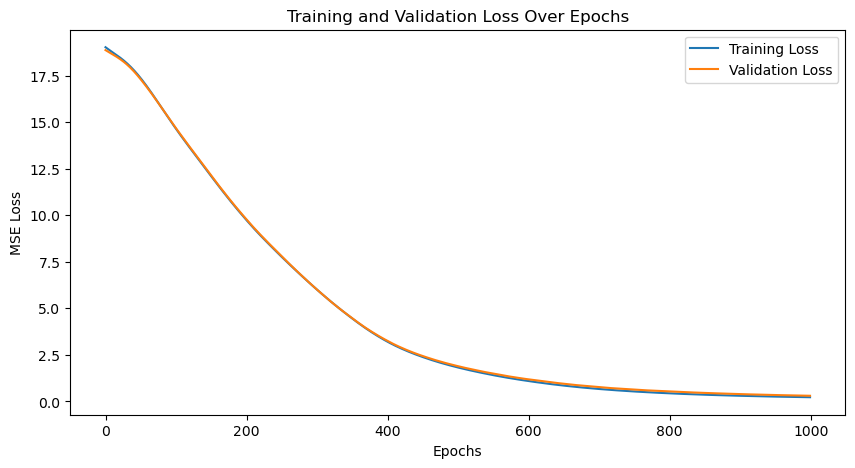

New best model found with MSE: 0.3026
Validation Metrics - MSE: 0.3026, MAE: 0.2339, R2: 0.9840

Fold 2/20
Epoch 20/1000 | Train Loss: 18.3766 | Val Loss: 17.8593
Epoch 40/1000 | Train Loss: 17.5891 | Val Loss: 17.0602
Epoch 60/1000 | Train Loss: 16.5727 | Val Loss: 16.0356
Epoch 80/1000 | Train Loss: 15.4386 | Val Loss: 14.8913
Epoch 100/1000 | Train Loss: 14.2955 | Val Loss: 13.7428
Epoch 120/1000 | Train Loss: 13.2175 | Val Loss: 12.6794
Epoch 140/1000 | Train Loss: 12.2064 | Val Loss: 11.7018
Epoch 160/1000 | Train Loss: 11.2400 | Val Loss: 10.7818
Epoch 180/1000 | Train Loss: 10.3032 | Val Loss: 9.8915
Epoch 200/1000 | Train Loss: 9.4175 | Val Loss: 9.0541
Epoch 220/1000 | Train Loss: 8.5989 | Val Loss: 8.2856
Epoch 240/1000 | Train Loss: 7.8593 | Val Loss: 7.5873
Epoch 260/1000 | Train Loss: 7.1883 | Val Loss: 6.9455
Epoch 280/1000 | Train Loss: 6.5645 | Val Loss: 6.3437
Epoch 300/1000 | Train Loss: 5.9769 | Val Loss: 5.7837
Epoch 320/1000 | Train Loss: 5.4275 | Val Loss: 5.2621


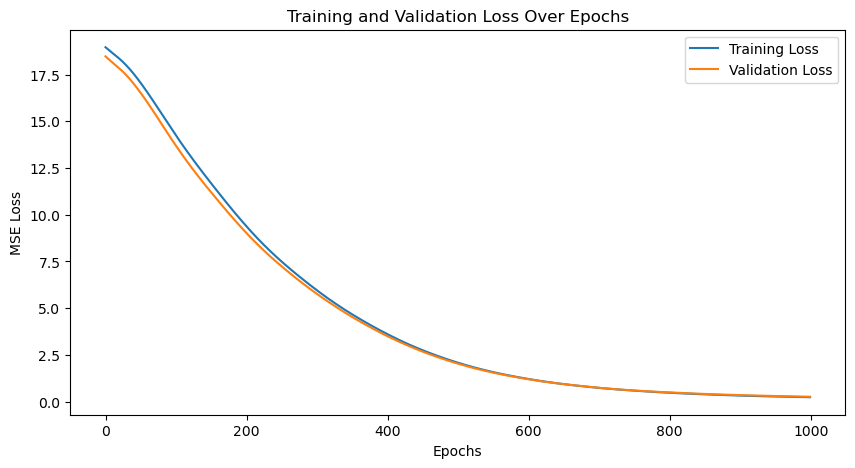

New best model found with MSE: 0.2568
Validation Metrics - MSE: 0.2568, MAE: 0.2047, R2: 0.9861

Fold 3/20
Epoch 20/1000 | Train Loss: 18.4547 | Val Loss: 18.5500
Epoch 40/1000 | Train Loss: 17.7219 | Val Loss: 17.8404
Epoch 60/1000 | Train Loss: 16.7424 | Val Loss: 16.8626
Epoch 80/1000 | Train Loss: 15.6255 | Val Loss: 15.7382
Epoch 100/1000 | Train Loss: 14.5238 | Val Loss: 14.6299
Epoch 120/1000 | Train Loss: 13.5179 | Val Loss: 13.6150
Epoch 140/1000 | Train Loss: 12.6041 | Val Loss: 12.6907
Epoch 160/1000 | Train Loss: 11.7302 | Val Loss: 11.8227
Epoch 180/1000 | Train Loss: 10.8866 | Val Loss: 10.9819
Epoch 200/1000 | Train Loss: 10.0894 | Val Loss: 10.1937
Epoch 220/1000 | Train Loss: 9.3172 | Val Loss: 9.4367
Epoch 240/1000 | Train Loss: 8.5539 | Val Loss: 8.6858
Epoch 260/1000 | Train Loss: 7.7985 | Val Loss: 7.9337
Epoch 280/1000 | Train Loss: 7.0471 | Val Loss: 7.1908
Epoch 300/1000 | Train Loss: 6.3126 | Val Loss: 6.4663
Epoch 320/1000 | Train Loss: 5.5909 | Val Loss: 5.74

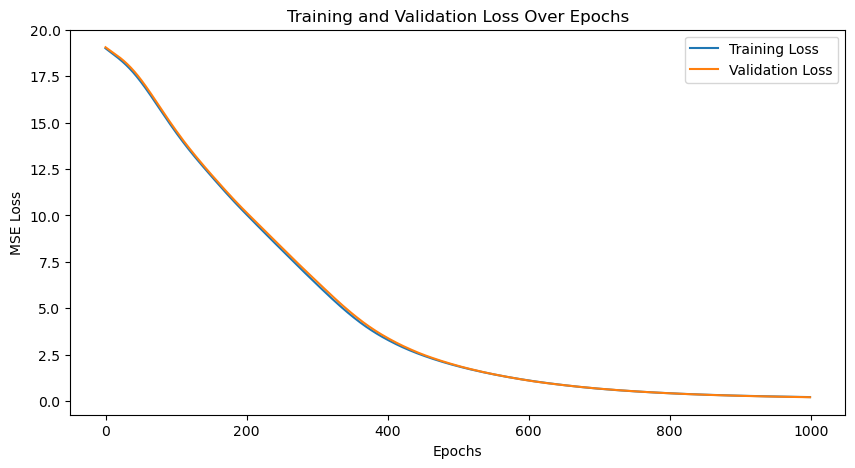

New best model found with MSE: 0.2036
Validation Metrics - MSE: 0.2036, MAE: 0.2109, R2: 0.9893

Fold 4/20
Epoch 20/1000 | Train Loss: 18.3947 | Val Loss: 19.2253
Epoch 40/1000 | Train Loss: 17.6772 | Val Loss: 18.5045
Epoch 60/1000 | Train Loss: 16.7400 | Val Loss: 17.5817
Epoch 80/1000 | Train Loss: 15.6511 | Val Loss: 16.5177
Epoch 100/1000 | Train Loss: 14.5227 | Val Loss: 15.4251
Epoch 120/1000 | Train Loss: 13.4123 | Val Loss: 14.3388
Epoch 140/1000 | Train Loss: 12.3303 | Val Loss: 13.2491
Epoch 160/1000 | Train Loss: 11.2717 | Val Loss: 12.1558
Epoch 180/1000 | Train Loss: 10.2500 | Val Loss: 11.0844
Epoch 200/1000 | Train Loss: 9.3086 | Val Loss: 10.0797
Epoch 220/1000 | Train Loss: 8.4516 | Val Loss: 9.1570
Epoch 240/1000 | Train Loss: 7.6521 | Val Loss: 8.3073
Epoch 260/1000 | Train Loss: 6.8900 | Val Loss: 7.4897
Epoch 280/1000 | Train Loss: 6.1652 | Val Loss: 6.7028
Epoch 300/1000 | Train Loss: 5.4822 | Val Loss: 5.9715
Epoch 320/1000 | Train Loss: 4.8424 | Val Loss: 5.289

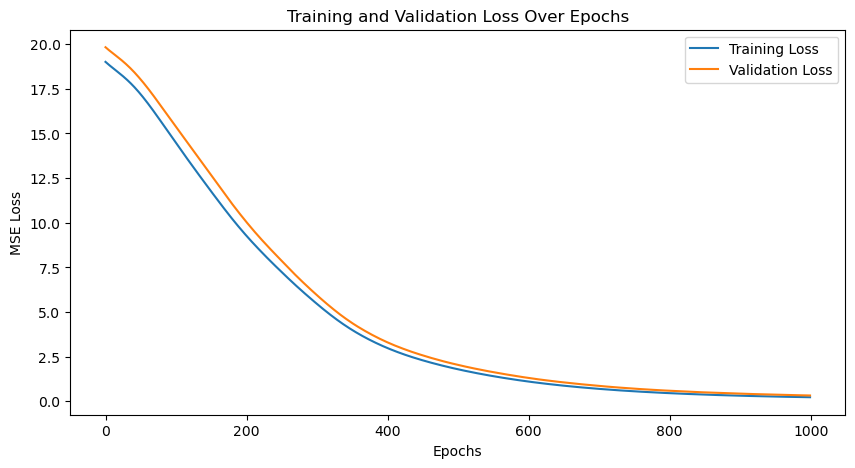

Validation Metrics - MSE: 0.3260, MAE: 0.2388, R2: 0.9835

Fold 5/20
Epoch 20/1000 | Train Loss: 18.4887 | Val Loss: 18.0754
Epoch 40/1000 | Train Loss: 17.7591 | Val Loss: 17.3721
Epoch 60/1000 | Train Loss: 16.7998 | Val Loss: 16.4382
Epoch 80/1000 | Train Loss: 15.6809 | Val Loss: 15.3511
Epoch 100/1000 | Train Loss: 14.5495 | Val Loss: 14.2333
Epoch 120/1000 | Train Loss: 13.4701 | Val Loss: 13.1555
Epoch 140/1000 | Train Loss: 12.4545 | Val Loss: 12.1530
Epoch 160/1000 | Train Loss: 11.4670 | Val Loss: 11.1946
Epoch 180/1000 | Train Loss: 10.4795 | Val Loss: 10.2425
Epoch 200/1000 | Train Loss: 9.5172 | Val Loss: 9.3291
Epoch 220/1000 | Train Loss: 8.5944 | Val Loss: 8.4474
Epoch 240/1000 | Train Loss: 7.7010 | Val Loss: 7.5916
Epoch 260/1000 | Train Loss: 6.8382 | Val Loss: 6.7471
Epoch 280/1000 | Train Loss: 6.0296 | Val Loss: 5.9613
Epoch 300/1000 | Train Loss: 5.2989 | Val Loss: 5.2531
Epoch 320/1000 | Train Loss: 4.6557 | Val Loss: 4.6352
Epoch 340/1000 | Train Loss: 4.0948 |

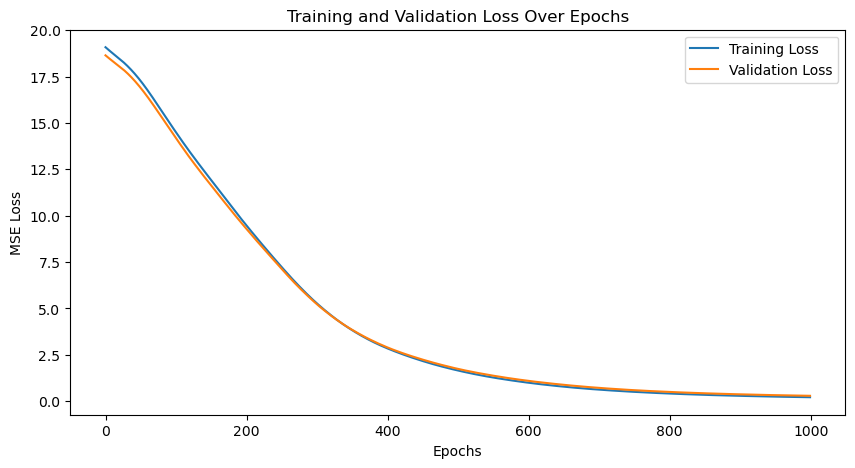

Validation Metrics - MSE: 0.2911, MAE: 0.2049, R2: 0.9843

Fold 6/20
Epoch 20/1000 | Train Loss: 18.5391 | Val Loss: 18.7367
Epoch 40/1000 | Train Loss: 17.8530 | Val Loss: 18.0687
Epoch 60/1000 | Train Loss: 16.9051 | Val Loss: 17.1236
Epoch 80/1000 | Train Loss: 15.7779 | Val Loss: 15.9821
Epoch 100/1000 | Train Loss: 14.6557 | Val Loss: 14.8556
Epoch 120/1000 | Train Loss: 13.6564 | Val Loss: 13.8484
Epoch 140/1000 | Train Loss: 12.7864 | Val Loss: 12.9692
Epoch 160/1000 | Train Loss: 11.9943 | Val Loss: 12.1469
Epoch 180/1000 | Train Loss: 11.2223 | Val Loss: 11.3475
Epoch 200/1000 | Train Loss: 10.4419 | Val Loss: 10.5475
Epoch 220/1000 | Train Loss: 9.6411 | Val Loss: 9.7213
Epoch 240/1000 | Train Loss: 8.7919 | Val Loss: 8.8487
Epoch 260/1000 | Train Loss: 7.8947 | Val Loss: 7.9184
Epoch 280/1000 | Train Loss: 6.9999 | Val Loss: 7.0117
Epoch 300/1000 | Train Loss: 6.1555 | Val Loss: 6.1634
Epoch 320/1000 | Train Loss: 5.3979 | Val Loss: 5.4162
Epoch 340/1000 | Train Loss: 4.7326

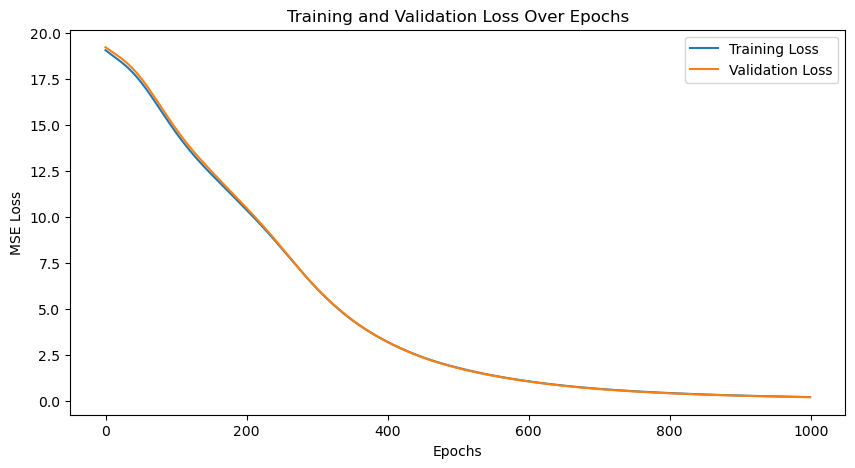

Validation Metrics - MSE: 0.2205, MAE: 0.2238, R2: 0.9885

Fold 7/20
Epoch 20/1000 | Train Loss: 18.2714 | Val Loss: 18.8563
Epoch 40/1000 | Train Loss: 17.3991 | Val Loss: 17.9608
Epoch 60/1000 | Train Loss: 16.3159 | Val Loss: 16.8460
Epoch 80/1000 | Train Loss: 15.2036 | Val Loss: 15.7092
Epoch 100/1000 | Train Loss: 14.1694 | Val Loss: 14.6590
Epoch 120/1000 | Train Loss: 13.2268 | Val Loss: 13.7068
Epoch 140/1000 | Train Loss: 12.3291 | Val Loss: 12.7921
Epoch 160/1000 | Train Loss: 11.4261 | Val Loss: 11.8448
Epoch 180/1000 | Train Loss: 10.5032 | Val Loss: 10.8793
Epoch 200/1000 | Train Loss: 9.5655 | Val Loss: 9.9235
Epoch 220/1000 | Train Loss: 8.6173 | Val Loss: 8.9653
Epoch 240/1000 | Train Loss: 7.6873 | Val Loss: 8.0189
Epoch 260/1000 | Train Loss: 6.7960 | Val Loss: 7.1104
Epoch 280/1000 | Train Loss: 5.9685 | Val Loss: 6.2568
Epoch 300/1000 | Train Loss: 5.2180 | Val Loss: 5.4896
Epoch 320/1000 | Train Loss: 4.5544 | Val Loss: 4.8148
Epoch 340/1000 | Train Loss: 3.9703 |

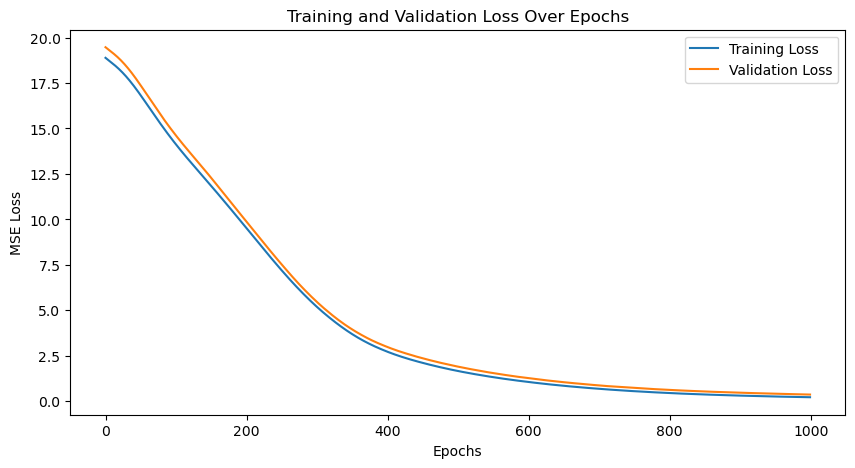

Validation Metrics - MSE: 0.3688, MAE: 0.2305, R2: 0.9812

Fold 8/20
Epoch 20/1000 | Train Loss: 18.4207 | Val Loss: 18.4266
Epoch 40/1000 | Train Loss: 17.6465 | Val Loss: 17.6574
Epoch 60/1000 | Train Loss: 16.6670 | Val Loss: 16.7076
Epoch 80/1000 | Train Loss: 15.5702 | Val Loss: 15.6564
Epoch 100/1000 | Train Loss: 14.4707 | Val Loss: 14.6092
Epoch 120/1000 | Train Loss: 13.4597 | Val Loss: 13.6544
Epoch 140/1000 | Train Loss: 12.5200 | Val Loss: 12.7657
Epoch 160/1000 | Train Loss: 11.6027 | Val Loss: 11.8820
Epoch 180/1000 | Train Loss: 10.6892 | Val Loss: 10.9752
Epoch 200/1000 | Train Loss: 9.8067 | Val Loss: 10.0895
Epoch 220/1000 | Train Loss: 8.9548 | Val Loss: 9.2229
Epoch 240/1000 | Train Loss: 8.1340 | Val Loss: 8.3653
Epoch 260/1000 | Train Loss: 7.3517 | Val Loss: 7.5519
Epoch 280/1000 | Train Loss: 6.5964 | Val Loss: 6.7665
Epoch 300/1000 | Train Loss: 5.8646 | Val Loss: 6.0161
Epoch 320/1000 | Train Loss: 5.1726 | Val Loss: 5.3182
Epoch 340/1000 | Train Loss: 4.5604 

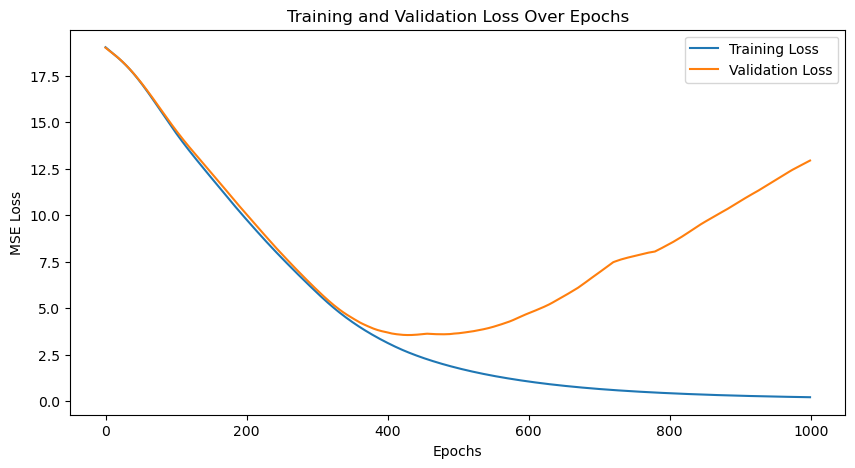

Validation Metrics - MSE: 12.9394, MAE: 0.2631, R2: 0.3177

Fold 9/20
Epoch 20/1000 | Train Loss: 18.5021 | Val Loss: 18.9261
Epoch 40/1000 | Train Loss: 17.8244 | Val Loss: 18.2802
Epoch 60/1000 | Train Loss: 16.9033 | Val Loss: 17.3795
Epoch 80/1000 | Train Loss: 15.7945 | Val Loss: 16.2888
Epoch 100/1000 | Train Loss: 14.6509 | Val Loss: 15.1676
Epoch 120/1000 | Train Loss: 13.5779 | Val Loss: 14.1115
Epoch 140/1000 | Train Loss: 12.5782 | Val Loss: 13.1106
Epoch 160/1000 | Train Loss: 11.6001 | Val Loss: 12.1083
Epoch 180/1000 | Train Loss: 10.6386 | Val Loss: 11.1050
Epoch 200/1000 | Train Loss: 9.7044 | Val Loss: 10.1281
Epoch 220/1000 | Train Loss: 8.8027 | Val Loss: 9.1860
Epoch 240/1000 | Train Loss: 7.9317 | Val Loss: 8.2809
Epoch 260/1000 | Train Loss: 7.1125 | Val Loss: 7.4312
Epoch 280/1000 | Train Loss: 6.3482 | Val Loss: 6.6352
Epoch 300/1000 | Train Loss: 5.6262 | Val Loss: 5.8877
Epoch 320/1000 | Train Loss: 4.9486 | Val Loss: 5.1831
Epoch 340/1000 | Train Loss: 4.3184

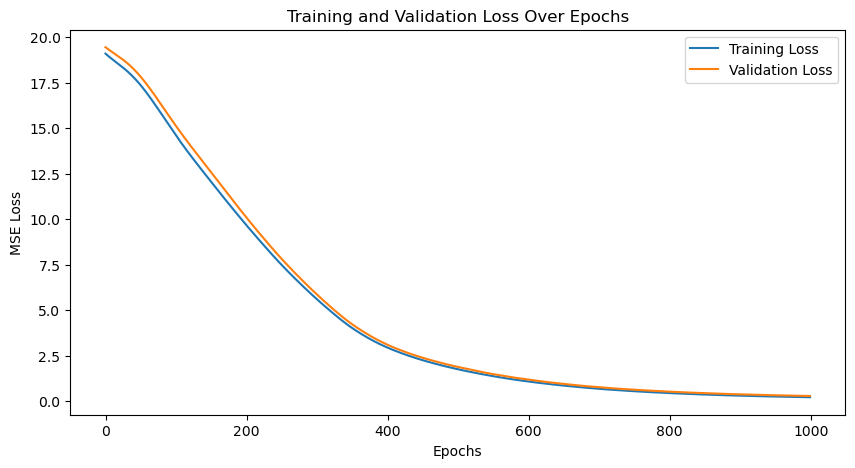

Validation Metrics - MSE: 0.2824, MAE: 0.2217, R2: 0.9854

Fold 10/20
Epoch 20/1000 | Train Loss: 18.6265 | Val Loss: 17.8736
Epoch 40/1000 | Train Loss: 17.9747 | Val Loss: 17.2412
Epoch 60/1000 | Train Loss: 17.0525 | Val Loss: 16.3390
Epoch 80/1000 | Train Loss: 15.9356 | Val Loss: 15.2503
Epoch 100/1000 | Train Loss: 14.7634 | Val Loss: 14.1123
Epoch 120/1000 | Train Loss: 13.6325 | Val Loss: 13.0207
Epoch 140/1000 | Train Loss: 12.5318 | Val Loss: 11.9533
Epoch 160/1000 | Train Loss: 11.4291 | Val Loss: 10.8906
Epoch 180/1000 | Train Loss: 10.3352 | Val Loss: 9.8395
Epoch 200/1000 | Train Loss: 9.3020 | Val Loss: 8.8572
Epoch 220/1000 | Train Loss: 8.3368 | Val Loss: 7.9245
Epoch 240/1000 | Train Loss: 7.4448 | Val Loss: 7.0663
Epoch 260/1000 | Train Loss: 6.6324 | Val Loss: 6.2839
Epoch 280/1000 | Train Loss: 5.8802 | Val Loss: 5.5605
Epoch 300/1000 | Train Loss: 5.1785 | Val Loss: 4.8745
Epoch 320/1000 | Train Loss: 4.5313 | Val Loss: 4.2545
Epoch 340/1000 | Train Loss: 3.9606 |

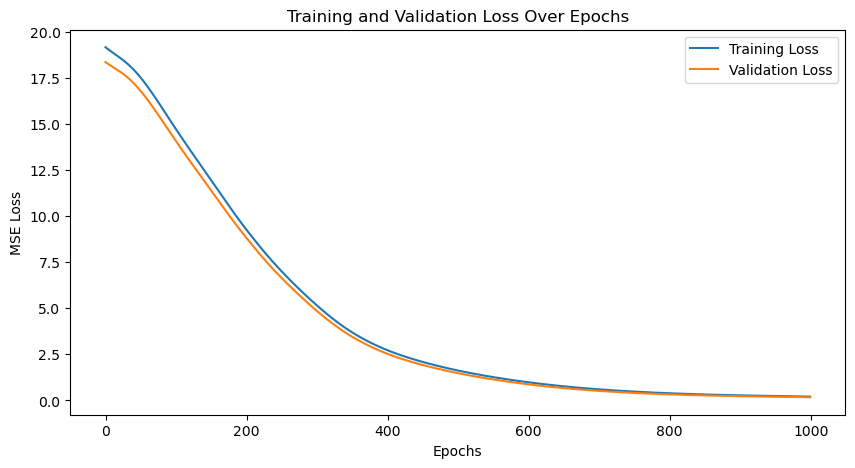

New best model found with MSE: 0.1746
Validation Metrics - MSE: 0.1746, MAE: 0.1963, R2: 0.9904

Fold 11/20
Epoch 20/1000 | Train Loss: 18.6300 | Val Loss: 18.3759
Epoch 40/1000 | Train Loss: 17.9435 | Val Loss: 17.7465
Epoch 60/1000 | Train Loss: 17.0321 | Val Loss: 16.9055
Epoch 80/1000 | Train Loss: 15.9222 | Val Loss: 15.8854
Epoch 100/1000 | Train Loss: 14.7532 | Val Loss: 14.8174
Epoch 120/1000 | Train Loss: 13.6307 | Val Loss: 13.7863
Epoch 140/1000 | Train Loss: 12.5797 | Val Loss: 12.8055
Epoch 160/1000 | Train Loss: 11.5627 | Val Loss: 11.8459
Epoch 180/1000 | Train Loss: 10.5507 | Val Loss: 10.8835
Epoch 200/1000 | Train Loss: 9.5845 | Val Loss: 9.9832
Epoch 220/1000 | Train Loss: 8.7029 | Val Loss: 9.2285
Epoch 240/1000 | Train Loss: 7.9135 | Val Loss: 8.6475
Epoch 260/1000 | Train Loss: 7.1970 | Val Loss: 8.2557
Epoch 280/1000 | Train Loss: 6.5289 | Val Loss: 8.0646
Epoch 300/1000 | Train Loss: 5.8924 | Val Loss: 8.0533
Epoch 320/1000 | Train Loss: 5.2859 | Val Loss: 8.129

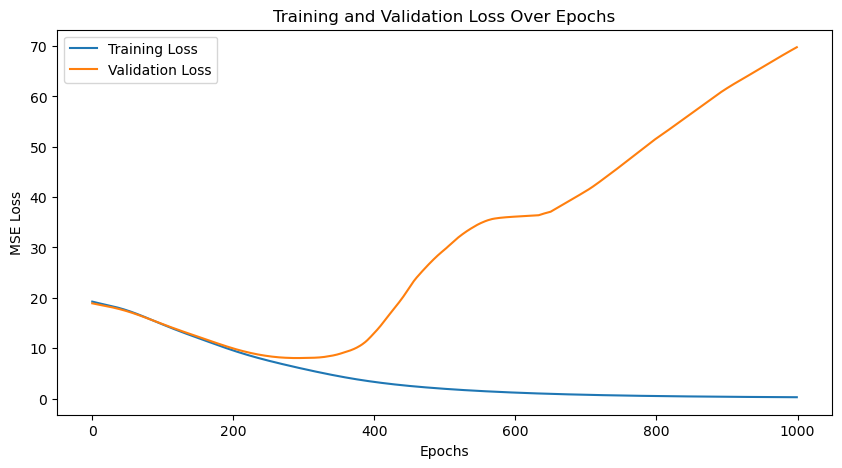

Validation Metrics - MSE: 69.7694, MAE: 0.4691, R2: -2.7448

Fold 12/20
Epoch 20/1000 | Train Loss: 18.4076 | Val Loss: 18.9808
Epoch 40/1000 | Train Loss: 17.6845 | Val Loss: 18.2145
Epoch 60/1000 | Train Loss: 16.7395 | Val Loss: 17.1852
Epoch 80/1000 | Train Loss: 15.6556 | Val Loss: 15.9990
Epoch 100/1000 | Train Loss: 14.5791 | Val Loss: 14.8094
Epoch 120/1000 | Train Loss: 13.5937 | Val Loss: 13.7290
Epoch 140/1000 | Train Loss: 12.6861 | Val Loss: 12.7702
Epoch 160/1000 | Train Loss: 11.8123 | Val Loss: 11.8703
Epoch 180/1000 | Train Loss: 10.9680 | Val Loss: 11.0068
Epoch 200/1000 | Train Loss: 10.1639 | Val Loss: 10.2112
Epoch 220/1000 | Train Loss: 9.3619 | Val Loss: 9.4576
Epoch 240/1000 | Train Loss: 8.5602 | Val Loss: 8.7134
Epoch 260/1000 | Train Loss: 7.7615 | Val Loss: 7.9632
Epoch 280/1000 | Train Loss: 6.9655 | Val Loss: 7.2453
Epoch 300/1000 | Train Loss: 6.2026 | Val Loss: 6.5803
Epoch 320/1000 | Train Loss: 5.4803 | Val Loss: 5.9820
Epoch 340/1000 | Train Loss: 4.8

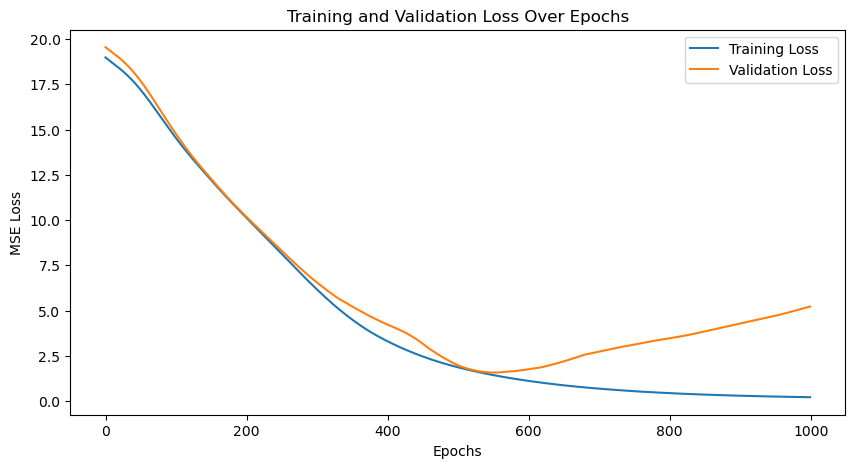

Validation Metrics - MSE: 5.2263, MAE: 0.2562, R2: 0.7332

Fold 13/20
Epoch 20/1000 | Train Loss: 18.4293 | Val Loss: 18.2438
Epoch 40/1000 | Train Loss: 17.6726 | Val Loss: 17.5210
Epoch 60/1000 | Train Loss: 16.6750 | Val Loss: 16.5745
Epoch 80/1000 | Train Loss: 15.5223 | Val Loss: 15.4751
Epoch 100/1000 | Train Loss: 14.3682 | Val Loss: 14.3646
Epoch 120/1000 | Train Loss: 13.2674 | Val Loss: 13.2945
Epoch 140/1000 | Train Loss: 12.2287 | Val Loss: 12.2741
Epoch 160/1000 | Train Loss: 11.2414 | Val Loss: 11.3049
Epoch 180/1000 | Train Loss: 10.2941 | Val Loss: 10.3794
Epoch 200/1000 | Train Loss: 9.3968 | Val Loss: 9.5037
Epoch 220/1000 | Train Loss: 8.5595 | Val Loss: 8.6814
Epoch 240/1000 | Train Loss: 7.7652 | Val Loss: 7.8824
Epoch 260/1000 | Train Loss: 7.0120 | Val Loss: 7.1098
Epoch 280/1000 | Train Loss: 6.2869 | Val Loss: 6.3717
Epoch 300/1000 | Train Loss: 5.5825 | Val Loss: 5.6586
Epoch 320/1000 | Train Loss: 4.9106 | Val Loss: 4.9770
Epoch 340/1000 | Train Loss: 4.3095 

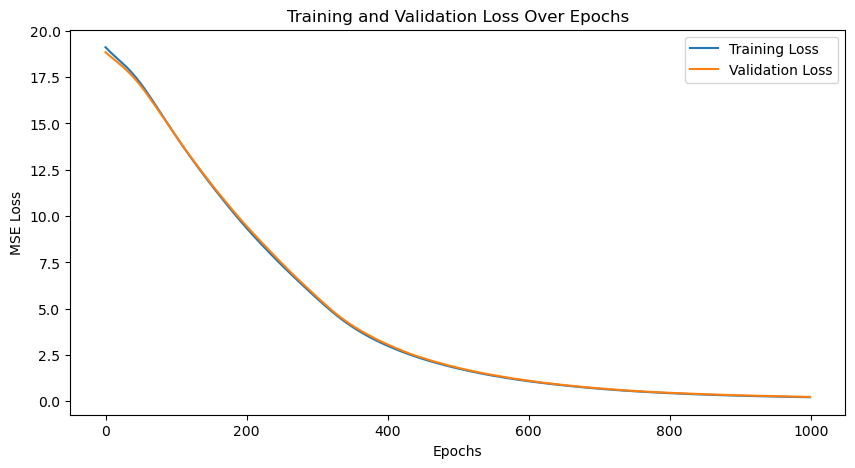

Validation Metrics - MSE: 0.2393, MAE: 0.2117, R2: 0.9873

Fold 14/20
Epoch 20/1000 | Train Loss: 18.6210 | Val Loss: 17.7992
Epoch 40/1000 | Train Loss: 18.0096 | Val Loss: 17.2286
Epoch 60/1000 | Train Loss: 17.1452 | Val Loss: 16.4096
Epoch 80/1000 | Train Loss: 16.0895 | Val Loss: 15.4192
Epoch 100/1000 | Train Loss: 14.9529 | Val Loss: 14.3798
Epoch 120/1000 | Train Loss: 13.8293 | Val Loss: 13.3597
Epoch 140/1000 | Train Loss: 12.7837 | Val Loss: 12.3967
Epoch 160/1000 | Train Loss: 11.7990 | Val Loss: 11.4591
Epoch 180/1000 | Train Loss: 10.8478 | Val Loss: 10.5316
Epoch 200/1000 | Train Loss: 9.9174 | Val Loss: 9.6114
Epoch 220/1000 | Train Loss: 9.0248 | Val Loss: 8.7311
Epoch 240/1000 | Train Loss: 8.1778 | Val Loss: 7.8787
Epoch 260/1000 | Train Loss: 7.3868 | Val Loss: 7.0814
Epoch 280/1000 | Train Loss: 6.6611 | Val Loss: 6.3487
Epoch 300/1000 | Train Loss: 6.0017 | Val Loss: 5.6913
Epoch 320/1000 | Train Loss: 5.3863 | Val Loss: 5.0913
Epoch 340/1000 | Train Loss: 4.8116 

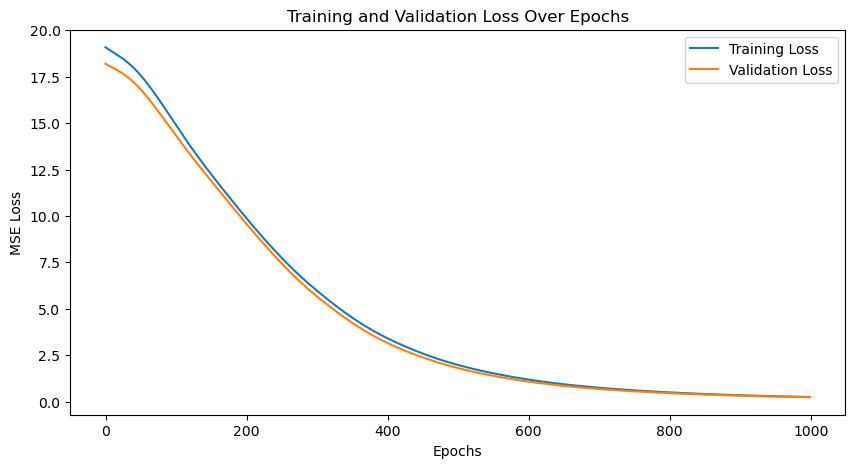

Validation Metrics - MSE: 0.2386, MAE: 0.2137, R2: 0.9869

Fold 15/20
Epoch 20/1000 | Train Loss: 18.4554 | Val Loss: 19.0815
Epoch 40/1000 | Train Loss: 17.7672 | Val Loss: 18.3698
Epoch 60/1000 | Train Loss: 16.8131 | Val Loss: 17.3655
Epoch 80/1000 | Train Loss: 15.7074 | Val Loss: 16.2162
Epoch 100/1000 | Train Loss: 14.6095 | Val Loss: 15.0913
Epoch 120/1000 | Train Loss: 13.5829 | Val Loss: 14.0442
Epoch 140/1000 | Train Loss: 12.5989 | Val Loss: 13.0217
Epoch 160/1000 | Train Loss: 11.6114 | Val Loss: 11.9852
Epoch 180/1000 | Train Loss: 10.6009 | Val Loss: 10.9349
Epoch 200/1000 | Train Loss: 9.5884 | Val Loss: 9.8941
Epoch 220/1000 | Train Loss: 8.6248 | Val Loss: 8.8884
Epoch 240/1000 | Train Loss: 7.7318 | Val Loss: 7.9568
Epoch 260/1000 | Train Loss: 6.8857 | Val Loss: 7.0768
Epoch 280/1000 | Train Loss: 6.0722 | Val Loss: 6.2237
Epoch 300/1000 | Train Loss: 5.3236 | Val Loss: 5.4567
Epoch 320/1000 | Train Loss: 4.6646 | Val Loss: 4.7799
Epoch 340/1000 | Train Loss: 4.0855 

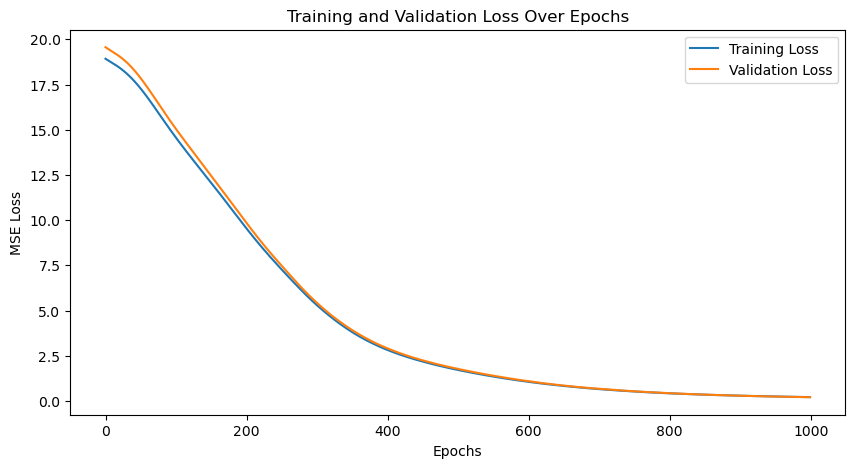

Validation Metrics - MSE: 0.2085, MAE: 0.2066, R2: 0.9893

Fold 16/20
Epoch 20/1000 | Train Loss: 18.5891 | Val Loss: 18.6474
Epoch 40/1000 | Train Loss: 17.9687 | Val Loss: 18.0773
Epoch 60/1000 | Train Loss: 17.1154 | Val Loss: 17.2431
Epoch 80/1000 | Train Loss: 16.0488 | Val Loss: 16.1794
Epoch 100/1000 | Train Loss: 14.9119 | Val Loss: 15.0471
Epoch 120/1000 | Train Loss: 13.8225 | Val Loss: 13.9649
Epoch 140/1000 | Train Loss: 12.8356 | Val Loss: 12.9802
Epoch 160/1000 | Train Loss: 11.9278 | Val Loss: 12.0728
Epoch 180/1000 | Train Loss: 11.0536 | Val Loss: 11.2045
Epoch 200/1000 | Train Loss: 10.2081 | Val Loss: 10.3577
Epoch 220/1000 | Train Loss: 9.3975 | Val Loss: 9.5439
Epoch 240/1000 | Train Loss: 8.6159 | Val Loss: 8.7576
Epoch 260/1000 | Train Loss: 7.8417 | Val Loss: 7.9762
Epoch 280/1000 | Train Loss: 7.0577 | Val Loss: 7.1932
Epoch 300/1000 | Train Loss: 6.2828 | Val Loss: 6.4230
Epoch 320/1000 | Train Loss: 5.5640 | Val Loss: 5.6924
Epoch 340/1000 | Train Loss: 4.904

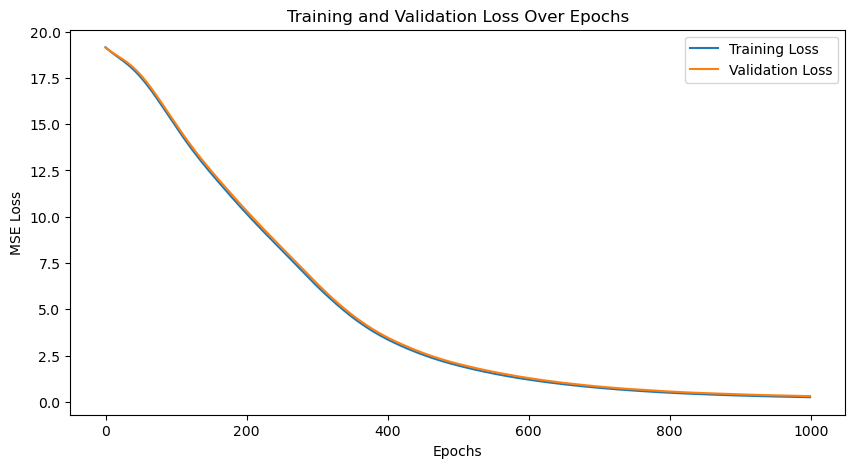

Validation Metrics - MSE: 0.3049, MAE: 0.2474, R2: 0.9840

Fold 17/20
Epoch 20/1000 | Train Loss: 18.6248 | Val Loss: 17.8886
Epoch 40/1000 | Train Loss: 17.9550 | Val Loss: 17.1766
Epoch 60/1000 | Train Loss: 17.0033 | Val Loss: 16.1863
Epoch 80/1000 | Train Loss: 15.8598 | Val Loss: 15.0068
Epoch 100/1000 | Train Loss: 14.7147 | Val Loss: 13.8375
Epoch 120/1000 | Train Loss: 13.6656 | Val Loss: 12.7839
Epoch 140/1000 | Train Loss: 12.7078 | Val Loss: 11.8658
Epoch 160/1000 | Train Loss: 11.7941 | Val Loss: 11.0382
Epoch 180/1000 | Train Loss: 10.8952 | Val Loss: 10.2402
Epoch 200/1000 | Train Loss: 9.9830 | Val Loss: 9.4292
Epoch 220/1000 | Train Loss: 9.0460 | Val Loss: 8.5837
Epoch 240/1000 | Train Loss: 8.1384 | Val Loss: 7.7559
Epoch 260/1000 | Train Loss: 7.3079 | Val Loss: 6.9939
Epoch 280/1000 | Train Loss: 6.5263 | Val Loss: 6.2683
Epoch 300/1000 | Train Loss: 5.7877 | Val Loss: 5.5720
Epoch 320/1000 | Train Loss: 5.1048 | Val Loss: 4.9233
Epoch 340/1000 | Train Loss: 4.4902 

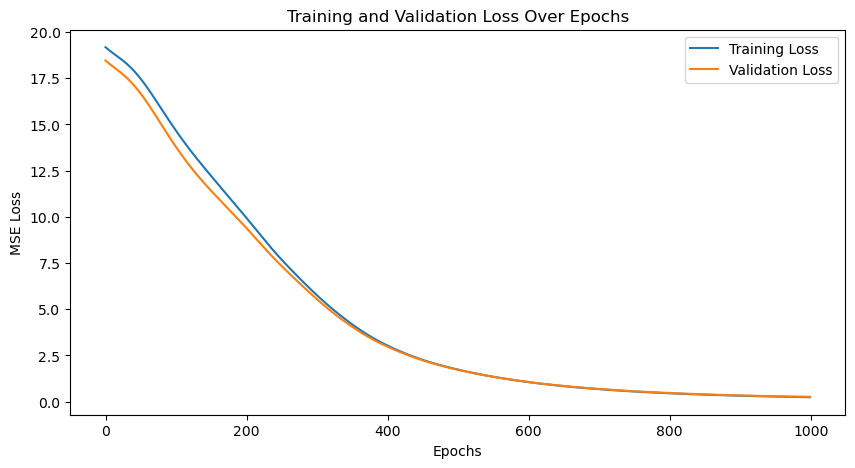

Validation Metrics - MSE: 0.2619, MAE: 0.2258, R2: 0.9857

Fold 18/20
Epoch 20/1000 | Train Loss: 18.4651 | Val Loss: 18.9318
Epoch 40/1000 | Train Loss: 17.7767 | Val Loss: 18.2158
Epoch 60/1000 | Train Loss: 16.8374 | Val Loss: 17.2123
Epoch 80/1000 | Train Loss: 15.7231 | Val Loss: 16.0170
Epoch 100/1000 | Train Loss: 14.5844 | Val Loss: 14.8065
Epoch 120/1000 | Train Loss: 13.5095 | Val Loss: 13.6790
Epoch 140/1000 | Train Loss: 12.4911 | Val Loss: 12.6360
Epoch 160/1000 | Train Loss: 11.4922 | Val Loss: 11.6248
Epoch 180/1000 | Train Loss: 10.5110 | Val Loss: 10.6541
Epoch 200/1000 | Train Loss: 9.5667 | Val Loss: 9.7398
Epoch 220/1000 | Train Loss: 8.6770 | Val Loss: 8.8968
Epoch 240/1000 | Train Loss: 7.8493 | Val Loss: 8.1443
Epoch 260/1000 | Train Loss: 7.0899 | Val Loss: 7.4785
Epoch 280/1000 | Train Loss: 6.3839 | Val Loss: 6.8338
Epoch 300/1000 | Train Loss: 5.7018 | Val Loss: 6.2275
Epoch 320/1000 | Train Loss: 5.0489 | Val Loss: 5.6810
Epoch 340/1000 | Train Loss: 4.4439 

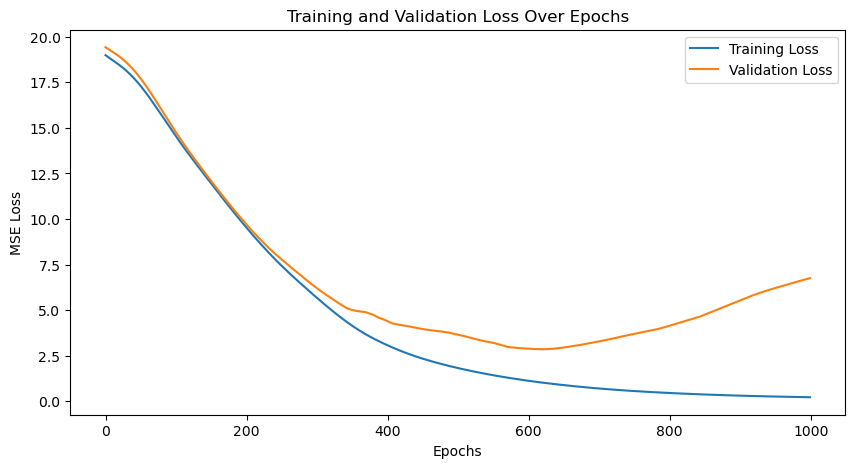

Validation Metrics - MSE: 6.7569, MAE: 0.2634, R2: 0.6523

Fold 19/20
Epoch 20/1000 | Train Loss: 18.6649 | Val Loss: 18.4296
Epoch 40/1000 | Train Loss: 18.0320 | Val Loss: 17.8149
Epoch 60/1000 | Train Loss: 17.1303 | Val Loss: 16.9082
Epoch 80/1000 | Train Loss: 15.9866 | Val Loss: 15.7740
Epoch 100/1000 | Train Loss: 14.7714 | Val Loss: 14.5956
Epoch 120/1000 | Train Loss: 13.6205 | Val Loss: 13.4999
Epoch 140/1000 | Train Loss: 12.5494 | Val Loss: 12.4899
Epoch 160/1000 | Train Loss: 11.5165 | Val Loss: 11.5035
Epoch 180/1000 | Train Loss: 10.5271 | Val Loss: 10.5540
Epoch 200/1000 | Train Loss: 9.5964 | Val Loss: 9.6572
Epoch 220/1000 | Train Loss: 8.7284 | Val Loss: 8.8000
Epoch 240/1000 | Train Loss: 7.8964 | Val Loss: 7.9771
Epoch 260/1000 | Train Loss: 7.0890 | Val Loss: 7.1736
Epoch 280/1000 | Train Loss: 6.3310 | Val Loss: 6.4070
Epoch 300/1000 | Train Loss: 5.6252 | Val Loss: 5.6801
Epoch 320/1000 | Train Loss: 4.9729 | Val Loss: 4.9996
Epoch 340/1000 | Train Loss: 4.3964 

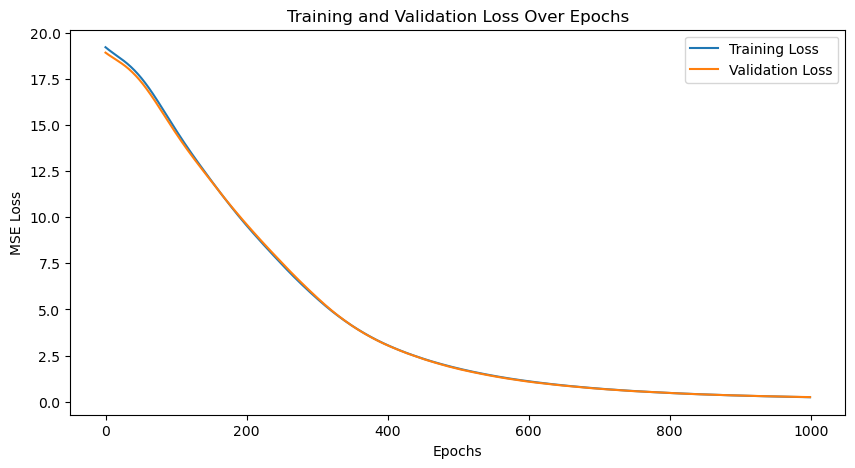

Validation Metrics - MSE: 0.2542, MAE: 0.2383, R2: 0.9864

Fold 20/20
Epoch 20/1000 | Train Loss: 18.5502 | Val Loss: 18.7247
Epoch 40/1000 | Train Loss: 17.8444 | Val Loss: 17.9937
Epoch 60/1000 | Train Loss: 16.9425 | Val Loss: 17.0339
Epoch 80/1000 | Train Loss: 15.8741 | Val Loss: 15.9160
Epoch 100/1000 | Train Loss: 14.7519 | Val Loss: 14.7533
Epoch 120/1000 | Train Loss: 13.6822 | Val Loss: 13.6539
Epoch 140/1000 | Train Loss: 12.7120 | Val Loss: 12.6605
Epoch 160/1000 | Train Loss: 11.8099 | Val Loss: 11.7468
Epoch 180/1000 | Train Loss: 10.9576 | Val Loss: 10.8977
Epoch 200/1000 | Train Loss: 10.1429 | Val Loss: 10.0842
Epoch 220/1000 | Train Loss: 9.3598 | Val Loss: 9.3080
Epoch 240/1000 | Train Loss: 8.6051 | Val Loss: 8.5634
Epoch 260/1000 | Train Loss: 7.8585 | Val Loss: 7.8316
Epoch 280/1000 | Train Loss: 7.1078 | Val Loss: 7.0876
Epoch 300/1000 | Train Loss: 6.3650 | Val Loss: 6.3587
Epoch 320/1000 | Train Loss: 5.6504 | Val Loss: 5.6625
Epoch 340/1000 | Train Loss: 4.981

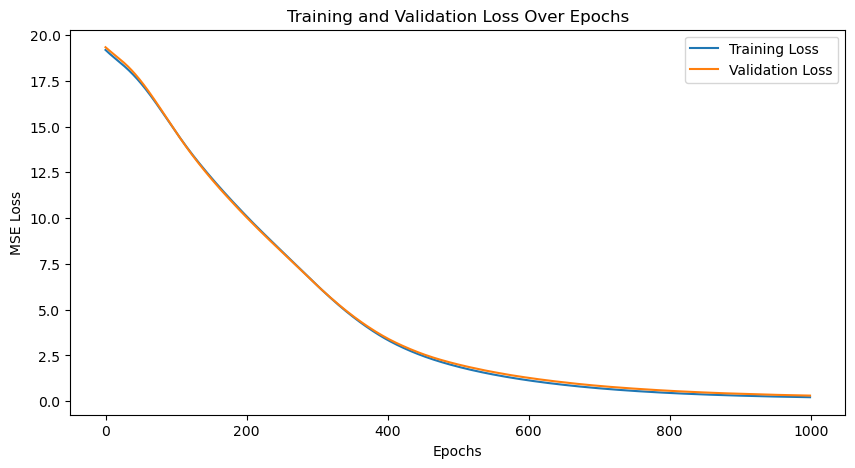

Validation Metrics - MSE: 0.3108, MAE: 0.2308, R2: 0.9838

Cross-Validation Summary:
Average MSE: 4.9468
Average MAE: 0.2396
Average R2: 0.7367
Best Model MSE: 0.1746


In [218]:
x_train = torch.FloatTensor(x_train)
x_test = torch.FloatTensor(x_test)
y_train = torch.FloatTensor(y_train).view(-1, 1)
y_test = torch.FloatTensor(y_test).view(-1, 1)

# K-Fold Cross Validation on Training Data
print("\nRunning K-Fold Cross Validation:")
results = kfold_cross_validation(x_train, y_train) #20 folds


Evaluation Metrics:
MSE: 0.2296
MAE: 0.2199
R2 Score: 0.9879


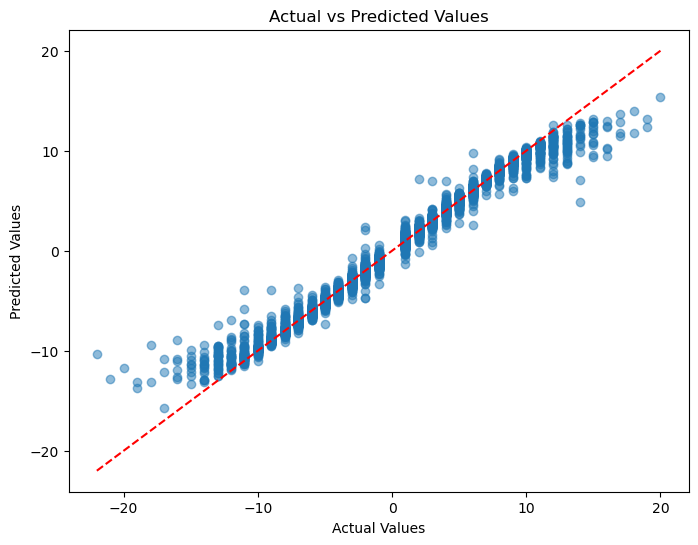

In [220]:
evaluate_model(results[0], x_test, y_test) #uses the best model from the kfold evaluation based on mse

#MAE is less sensitive to outliers
#MSE penalizes large errors more

In [221]:
#The model is good for predicting score difference but its a black box so its not as good
#at explaining the why. This is a large disadvantage for the use of sports analytics if your intent is to use it for 
#sport scouting or team building.

#only 1 hidden layer to prevent overfitting